In [1]:
#step 1
import pandas as pd
df = pd.read_csv(
    'train_FD001.txt', 
    sep = '\s+', #this split whenever one or more spaces or tabs appear
    header=None #because the file did not have any column names
) 
df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [2]:
#renaming the columns
columns =(
    ['engine_id', 'cycle']
    + [f'op{i}' for i in range (1, 4)] #using 'op' for operating points
    + [f's{i}' for i in range (1, 22)] #using 's' for sensor data
)
df.columns = columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   op1        20631 non-null  float64
 3   op2        20631 non-null  float64
 4   op3        20631 non-null  float64
 5   s1         20631 non-null  float64
 6   s2         20631 non-null  float64
 7   s3         20631 non-null  float64
 8   s4         20631 non-null  float64
 9   s5         20631 non-null  float64
 10  s6         20631 non-null  float64
 11  s7         20631 non-null  float64
 12  s8         20631 non-null  float64
 13  s9         20631 non-null  float64
 14  s10        20631 non-null  float64
 15  s11        20631 non-null  float64
 16  s12        20631 non-null  float64
 17  s13        20631 non-null  float64
 18  s14        20631 non-null  float64
 19  s15        20631 non-null  float64
 20  s16   

In [3]:
max_cycle = df.groupby('engine_id')['cycle'].max() #get teh maxmium nuber of cycles for each engine
df = df.merge(
    max_cycle.rename('max_cycle'), #assign this as a column to merge
    on='engine_id'
)
df['RUL'] = df['max_cycle'] - df['cycle']
df['RUL'].head()

0    191
1    190
2    189
3    188
4    187
Name: RUL, dtype: int64

In [4]:
df.head()

,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s14,s15,s16,s17,s18,s19,s20,s21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [5]:
df.isna().sum() #checked for null values
sensor_col = [f's{i}' for i in range(1,22)]
constant_sensors = df[sensor_col].columns[
    df[sensor_col].std()==0 #checked for zero standard deviation
    ]
print(constant_sensors)

Index(['s18', 's19'], dtype='object')


In [6]:

non_uniq = df[sensor_col].columns[
    df[sensor_col].nunique()==1
    ]
print(non_uniq)

Index(['s1', 's5', 's10', 's16', 's18', 's19'], dtype='object')


In [ ]:
import matplotlib.pyplot as plt
for sensors in sensor_col:
    plt.figure(figsize=(10,3))
    plt.plot(df[sensors].values[:1000]) #does not exceed over 1000 rows of sensor data
    plt.title(sensors)
    plt.show()

In [8]:
df.drop(columns= ['s1','s5','s10', 's16', 's18', 's19'], inplace = True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 22 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   op1        20631 non-null  float64
 3   op2        20631 non-null  float64
 4   op3        20631 non-null  float64
 5   s2         20631 non-null  float64
 6   s3         20631 non-null  float64
 7   s4         20631 non-null  float64
 8   s6         20631 non-null  float64
 9   s7         20631 non-null  float64
 10  s8         20631 non-null  float64
 11  s9         20631 non-null  float64
 12  s11        20631 non-null  float64
 13  s12        20631 non-null  float64
 14  s13        20631 non-null  float64
 15  s14        20631 non-null  float64
 16  s15        20631 non-null  float64
 17  s17        20631 non-null  int64  
 18  s20        20631 non-null  float64
 19  s21        20631 non-null  float64
 20  max_cy

In [10]:
sensor = 's9'

avg_sensor = (
    df.groupby('RUL')[sensor]
      .mean()
      .reset_index()
      .sort_values('RUL')
)
print(avg_sensor)

     RUL         s9
0      0  9099.3596
1      1  9099.6093
2      2  9098.0047
3      3  9097.1519
4      4  9095.8344
..   ...        ...
357  357  9064.6500
358  358  9061.8900
359  359  9052.7700
360  360  9057.5700
361  361  9054.1900

[362 rows x 2 columns]


In [11]:
avg_sensor['smooth'] = (
    avg_sensor[sensor]
        .rolling(window=20, center=True)
        .mean()
)

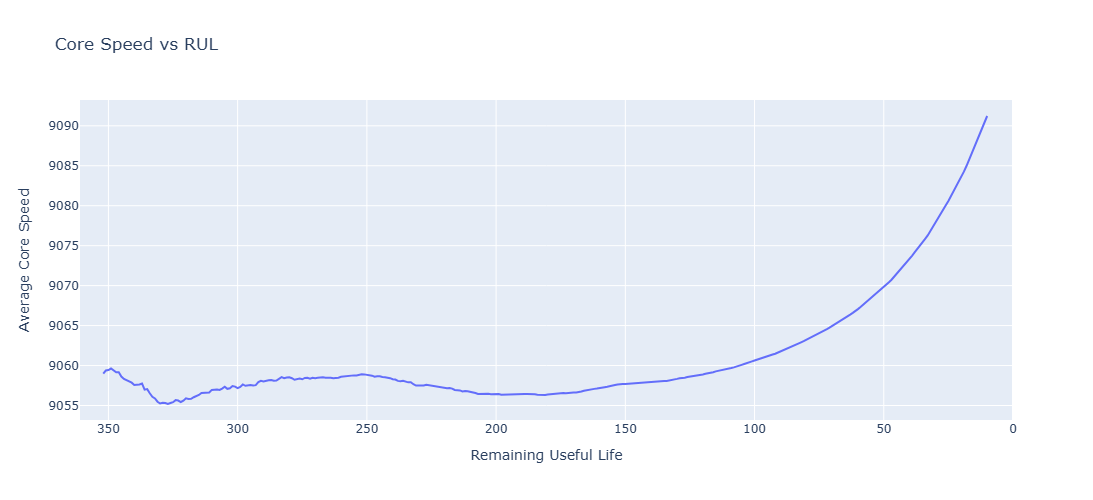

In [12]:
import plotly.express as px

fig = px.line(
    avg_sensor,
    x='RUL',
    y='smooth',
    title='Core Speed vs RUL',
    labels={
        'RUL': 'Remaining Useful Life',
        'smooth': 'Average Core Speed'
    }
)
fig.update_xaxes(autorange='reversed') #axis is reversed so it's easy to understand
fig.update_layout(
    width=1000,
    height=500,
    hovermode='x unified'
)
fig.show()

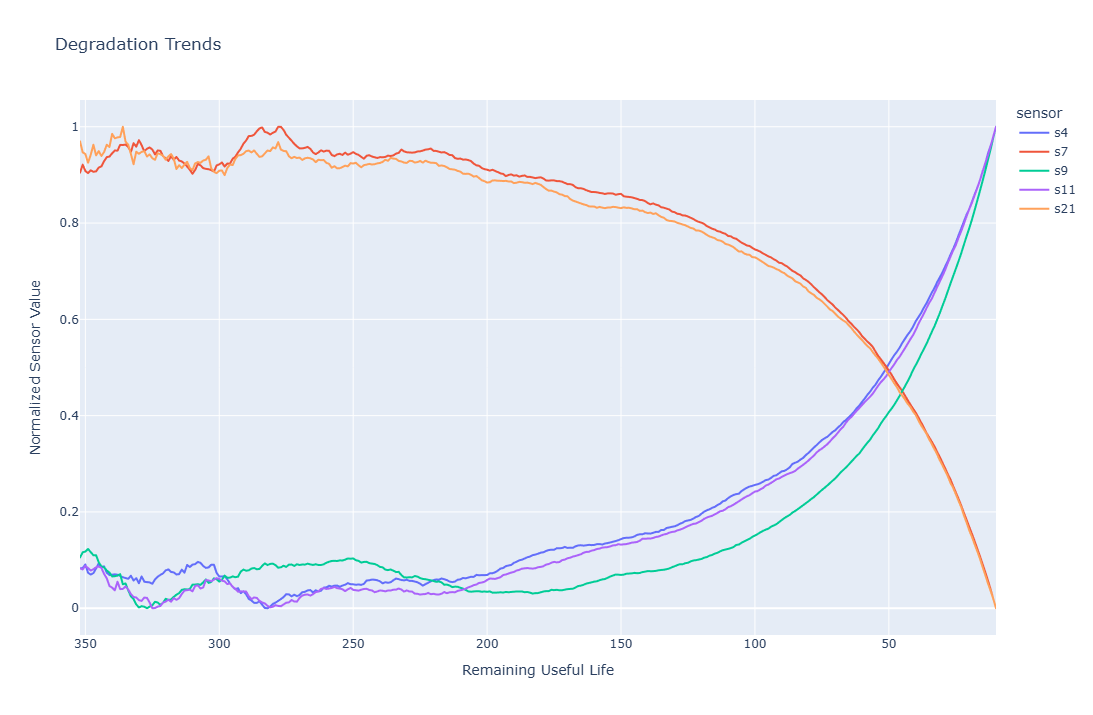

In [13]:
sensors = ['s4', 's7', 's9', 's11', 's21']
plot_df = pd.DataFrame()
for sensor in sensors: #looping through all the sensors 
    avg_sensor = (
        df.groupby('RUL')[sensor]
          .mean()
          .reset_index()
          .sort_values('RUL')
    )
    avg_sensor['smooth'] = (
        avg_sensor[sensor]
            .rolling(window=20, center=True)
            .mean()
    )
    avg_sensor = avg_sensor.dropna() #reove the null values if there are any
    avg_sensor['normalized'] = (avg_sensor['smooth'] - avg_sensor['smooth'].min()) / (avg_sensor['smooth'].max() - avg_sensor['smooth'].min())
    temp = avg_sensor[['RUL', 'normalized']].copy()
    temp['sensor'] = sensor
    plot_df = pd.concat([plot_df, temp])

fig = px.line(
    plot_df,
    x='RUL',
    y='normalized',
    color='sensor',
    title='Degradation Trends',
    labels={
        'RUL': 'Remaining Useful Life',
        'normalized': 'Normalized Sensor Value'
    }
)
fig.update_xaxes(
    autorange='reversed'
)
fig.update_layout(
    width=1200,
    height=700,
    hovermode='x unified'
)
fig.show()

In [14]:
engine_life = df.groupby('engine_id')['max_cycle'].first()
avg_life = engine_life.mean()
print(avg_life)

206.31


In [15]:
max_RUL = 128
df['RUL_clipped'] = df['RUL'].clip(upper=max_RUL)

In [16]:
print(df[['RUL', 'RUL_clipped']].head(10))
print(df['RUL_clipped'].max())

   RUL  RUL_clipped
0  191          128
1  190          128
2  189          128
3  188          128
4  187          128
5  186          128
6  185          128
7  184          128
8  183          128
9  182          128
128


In [17]:
import numpy as np
window_size = 30
X = []
y = []
for id in df['engine_id'].unique(): #looping through the engines 
    engine_data = df[df['engine_id'] == id] #extracting the engine data
    data = engine_data[sensors].values
    labels = engine_data['RUL_clipped'].values
    for i in range(len(engine_data) - window_size + 1): #sliding window of 30, predicting for 30 cycles
        X.append(data[i:i+window_size]) #so x becomes 30 times 5 sensor data
        y.append(labels[i + window_size - 1]) #each 30 cycle, the last cycle is predicted RUL

X = np.array(X)
y = np.array(y)

In [18]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17731, 30, 5)
y shape: (17731,)


In [ ]:
print(X[0])

In [20]:
print(X[0].shape)

(30, 5)


In [21]:
print(y[0])

128


In [ ]:
first_engine = df[df['engine_id'] == 1]
print(
    first_engine[['cycle', 'RUL_clipped']]
    .head(35)
)

In [23]:
print(y[0])

print(
    first_engine.iloc[29]['RUL_clipped']
)

128
128.0


In [24]:
print(np.isnan(X).sum())
print(np.isnan(y).sum())

0
0


In [25]:
from sklearn.ensemble import RandomForestRegressor

features = df.drop(columns=['engine_id', 'cycle', 'RUL', 'RUL_clipped', 'max_cycle']).columns # we drop these because the model should learn physics, not memorization
X_train = df[features] # training data (sensors and operating conditions)
y_train = df['RUL_clipped'] # target variable
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42) #instantiating the random forest model (100 trees, depth liits tree size to prevent overfitting)
rf_model.fit(X_train, y_train) # training the model

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
df_test = pd.read_csv('test_FD001.txt', sep='\s+', header=None)
df_test.columns = ['engine_id', 'cycle'] + [f'op{i}' for i in range(1, 4)] + [f's{i}' for i in range(1, 22)]

df_test.drop(columns= ['s1','s5','s10', 's16', 's18', 's19'], inplace = True)
df_test_last_cycle = df_test.groupby('engine_id').tail(1)
X_test = df_test_last_cycle[features]
predictions = rf_model.predict(X_test) # predict RUL

In [27]:
from sklearn.metrics import mean_squared_error
y_true = pd.read_csv('RUL_FD001.txt', sep='\s+', header=None, names=['Actual_RUL'])
mse = mean_squared_error(y_true['Actual_RUL'], predictions)
rmse = np.sqrt(mse)
print(f"Model RMSE: {rmse:.2f} cycles") # prints the RMSE value upto 2 decimals

comparison_df = pd.DataFrame({
    'Engine_ID': range(1, 6),
    'Predicted_RUL': predictions[:5].round(), # rounding off the first 5 predictions
    'Actual_RUL': y_true['Actual_RUL'][:5].values
})
print("\nSample Predictions vs Reality:")
print(comparison_df)

Model RMSE: 18.26 cycles

Sample Predictions vs Reality:
   Engine_ID  Predicted_RUL  Actual_RUL
0          1          122.0         112
1          2          117.0          98
2          3           65.0          69
3          4          103.0          82
4          5          103.0          91
